# EXPLORE AND VISUALIZATION DATA 

In [3]:
from datasets import load_dataset
ds = load_dataset("ehovy/race", "middle")

d:\anaconda\envs\rag_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import seaborn as sns

In [5]:
ds.column_names

{'test': ['example_id', 'article', 'answer', 'question', 'options'],
 'train': ['example_id', 'article', 'answer', 'question', 'options'],
 'validation': ['example_id', 'article', 'answer', 'question', 'options']}

In [6]:
ds['train'][0]

{'example_id': 'middle4558.txt',
 'article': '"I planted a seed. Finally grow fruits. Today is a great day. Pick off the star for you. Pick off the moon for you. Let it rise for you every day. Become candles burning myself. Just light you up, hey!... You are my little little apple. How much I love you, still no enough."\nThis words are from the popular song You Are My Little Dear Apple. Bae Seul-Ki acted as the leading dancer in the MV of the song. She loves dancing. She became crazy about hip-hop when she was a school girl.\nBai Seul-Ki was born on September 27, 1986. She is a South Korean singer and dancer. She is 168cm tall. She loves cooking. Her favourite food is spicy and salty. She like pink and red most. There are five members in her family---father, mother, two younger brothers and herself. She isn\'t married.\nAfter her father and mother broke up, she lived with her mother and new daddy. She enjoys being alone.',
 'answer': 'B',
 'question': 'Bae Seul-Ki   _   in the MV of th

In [7]:
ds['train'][0]["article"]

'"I planted a seed. Finally grow fruits. Today is a great day. Pick off the star for you. Pick off the moon for you. Let it rise for you every day. Become candles burning myself. Just light you up, hey!... You are my little little apple. How much I love you, still no enough."\nThis words are from the popular song You Are My Little Dear Apple. Bae Seul-Ki acted as the leading dancer in the MV of the song. She loves dancing. She became crazy about hip-hop when she was a school girl.\nBai Seul-Ki was born on September 27, 1986. She is a South Korean singer and dancer. She is 168cm tall. She loves cooking. Her favourite food is spicy and salty. She like pink and red most. There are five members in her family---father, mother, two younger brothers and herself. She isn\'t married.\nAfter her father and mother broke up, she lived with her mother and new daddy. She enjoys being alone.'

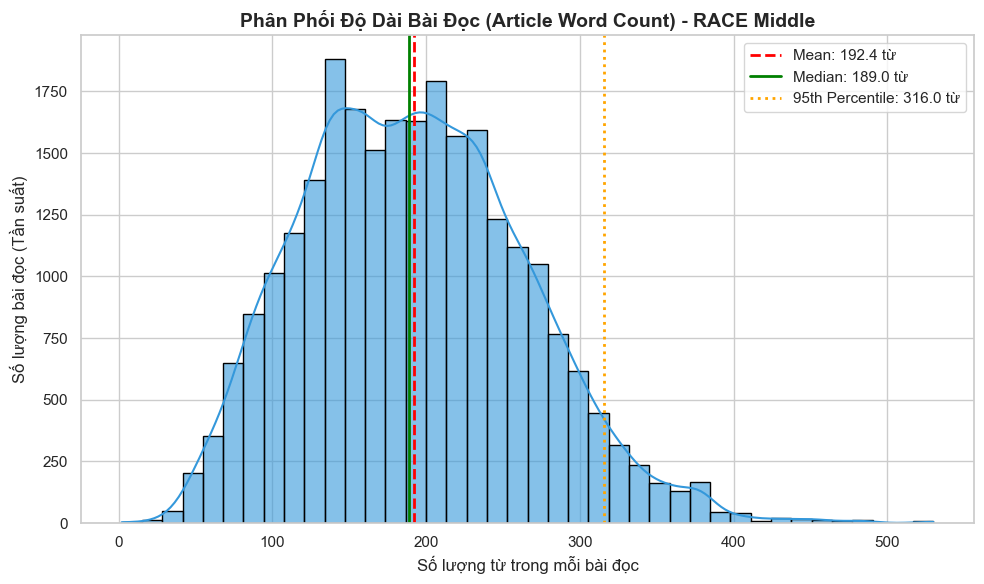

In [11]:
word_counts = [len(item["article"].split()) for item in ds['train']]

mean_val = np.mean(word_counts)
median_val = np.median(word_counts)
p95_val = np.percentile(word_counts, 95)

# histogram
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")


sns.histplot(
    word_counts,
    bins=40,
    kde=True,
    color="#3498db",
    edgecolor="black",
    alpha=0.6,
)

plt.axvline(
    mean_val,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {mean_val:.1f} từ",
)
plt.axvline(
    median_val,
    color="green",
    linestyle="-",
    linewidth=2,
    label=f"Median: {median_val:.1f} từ",
)
plt.axvline(
    p95_val,
    color="orange",
    linestyle=":",
    linewidth=2,
    label=f"95th Percentile: {p95_val:.1f} từ",
)

plt.title(
    "Phân Phối Độ Dài Bài Đọc (Article Word Count) - RACE Middle",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Số lượng từ trong mỗi bài đọc", fontsize=12)
plt.ylabel("Số lượng bài đọc (Tần suất)", fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()

Số đoạn văn trung bình trên mỗi bài: 5.1
Bài có số đoạn ít nhất: 1 | Nhiều nhất: 58
Phân vị thứ 50 (Median): 4
Phân vị thứ 95: 11


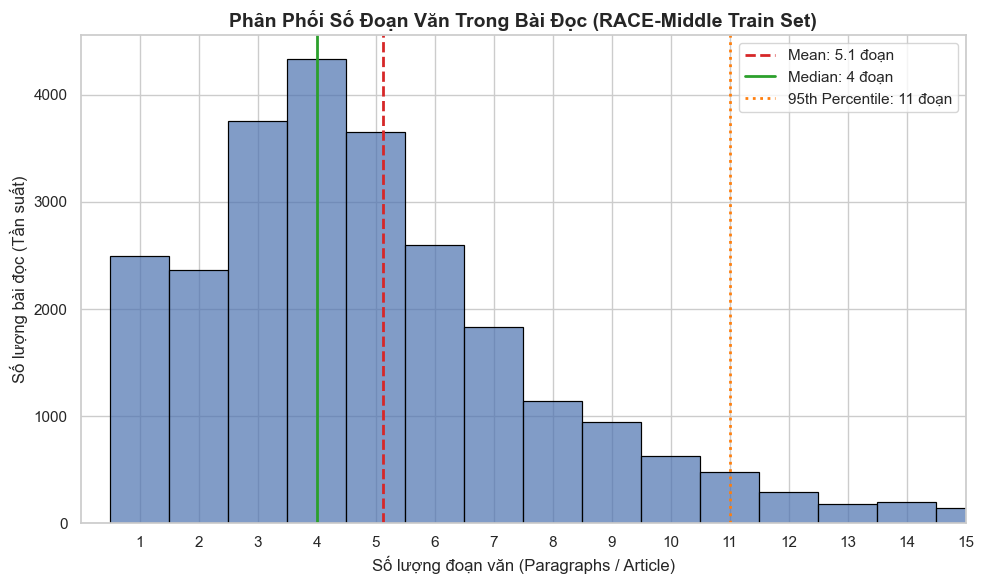

In [13]:
# 1. Tính số đoạn văn cho từng bài đọc
num_paragraphs = [len(item["article"].split("\n")) for item in ds["train"]]

# 2. Tính toán các chỉ số thống kê
mean_p = np.mean(num_paragraphs)
median_p = np.median(num_paragraphs)
p95_p = np.percentile(num_paragraphs, 95)
min_p = np.min(num_paragraphs)
max_p = np.max(num_paragraphs)

print(f"Số đoạn văn trung bình trên mỗi bài: {mean_p:.1f}")
print(f"Bài có số đoạn ít nhất: {min_p} | Nhiều nhất: {max_p}")
print(f"Phân vị thứ 50 (Median): {median_p:.0f}")
print(f"Phân vị thứ 95: {p95_p:.0f}")

# 3. Thiết lập biểu đồ Histogram
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Sử dụng bins tương ứng với các giá trị nguyên rời rạc
bins = np.arange(min_p, max_p + 2) - 0.5

sns.histplot(
    num_paragraphs,
    bins=bins,
    kde=False,
    color="#4C72B0",
    edgecolor="black",
    alpha=0.7,
)

# 4. Thêm các đường mốc thống kê quan trọng
plt.axvline(
    mean_p,
    color="#D62728",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {mean_p:.1f} đoạn",
)
plt.axvline(
    median_p,
    color="#2CA02C",
    linestyle="-",
    linewidth=2,
    label=f"Median: {median_p:.0f} đoạn",
)
plt.axvline(
    p95_p,
    color="#FF7F0E",
    linestyle=":",
    linewidth=2,
    label=f"95th Percentile: {p95_p:.0f} đoạn",
)

# Căn chỉnh tiêu đề và các trục
plt.title(
    "Phân Phối Số Đoạn Văn Trong Bài Đọc (RACE-Middle Train Set)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Số lượng đoạn văn (Paragraphs / Article)", fontsize=12)
plt.ylabel("Số lượng bài đọc (Tần suất)", fontsize=12)
plt.xticks(np.arange(min_p, min(max_p + 1, 20)))
plt.xlim(0, max(p95_p + 3, 15))
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()

[Article] Mean: 15.7 | Median: 15 | 95th: 26
[Paragraph] Mean: 3.3 | Median: 3 | 95th: 8


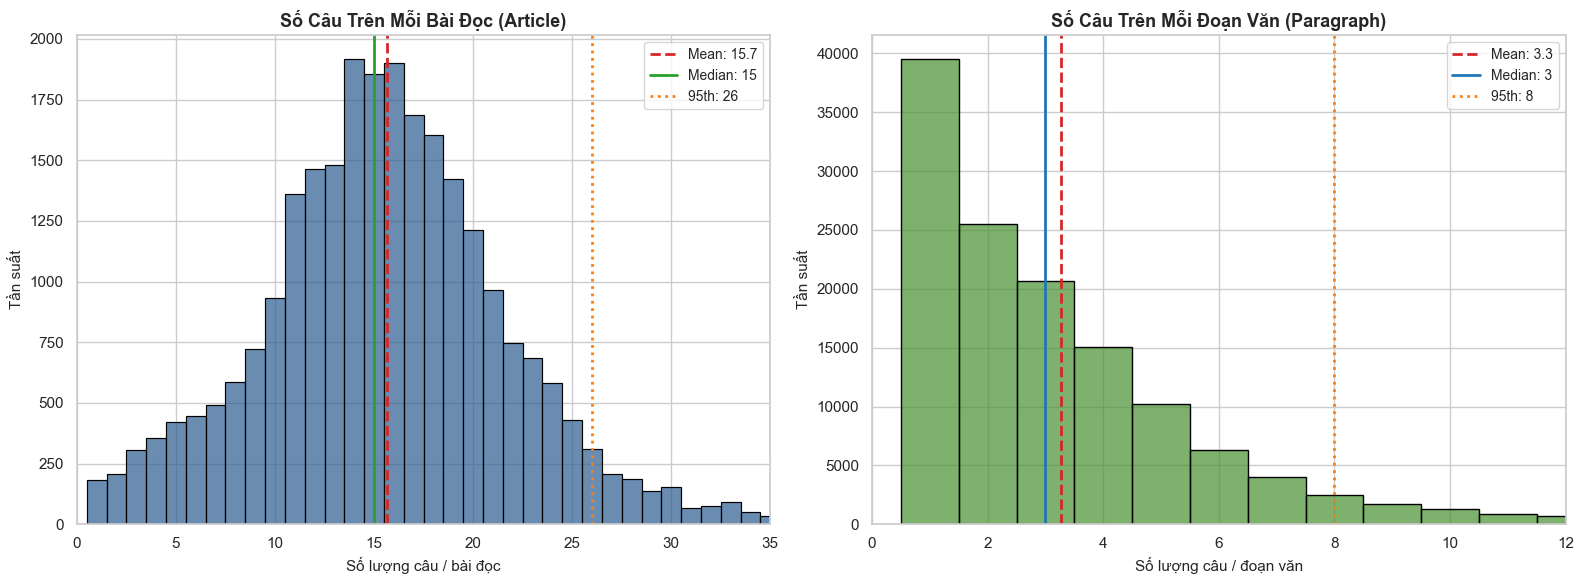

In [14]:
import re
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Khởi tạo bộ tách câu (dùng nltk punkt hoặc regex)
try:
    import nltk

    nltk.download("punkt", quiet=True)
    nltk.download("punkt_tab", quiet=True)
    from nltk.tokenize import sent_tokenize

    split_sentences = sent_tokenize
except Exception:
    # Regex fallback chuẩn cho tiếng Anh nếu không dùng nltk
    split_sentences = lambda text: [
        s.strip()
        for s in re.split(r"(?<=[.!?])\s+", text)
        if len(s.strip()) > 0
    ]

# 1. Thu thập số câu cho mỗi Article và mỗi Paragraph
sentences_per_article = []
sentences_per_paragraph = []

for item in ds["train"]:
    article_text = item["article"]

    # Đếm số câu trên toàn bài đọc
    article_sents = split_sentences(article_text)
    sentences_per_article.append(len(article_sents))

    # Tách theo từng đoạn văn (newline) và đếm số câu trong mỗi đoạn
    paragraphs = [p.strip() for p in article_text.split("\n") if p.strip()]
    for p in paragraphs:
        p_sents = split_sentences(p)
        if len(p_sents) > 0:
            sentences_per_paragraph.append(len(p_sents))

# 2. Tính toán các chỉ số thống kê
stats_article = {
    "mean": np.mean(sentences_per_article),
    "median": np.median(sentences_per_article),
    "p95": np.percentile(sentences_per_article, 95),
    "min": np.min(sentences_per_article),
    "max": np.max(sentences_per_article),
}

stats_paragraph = {
    "mean": np.mean(sentences_per_paragraph),
    "median": np.median(sentences_per_paragraph),
    "p95": np.percentile(sentences_per_paragraph, 95),
    "min": np.min(sentences_per_paragraph),
    "max": np.max(sentences_per_paragraph),
}

print(
    f"[Article] Mean: {stats_article['mean']:.1f} | Median: {stats_article['median']:.0f} | 95th: {stats_article['p95']:.0f}"
)
print(
    f"[Paragraph] Mean: {stats_paragraph['mean']:.1f} | Median: {stats_paragraph['median']:.0f} | 95th: {stats_paragraph['p95']:.0f}"
)

# 3. Vẽ 2 biểu đồ trực quan hóa
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# Biểu đồ 1: Số câu trên mỗi Article
bins_art = (
    np.arange(stats_article["min"], min(stats_article["max"] + 2, 45)) - 0.5
)
sns.histplot(
    sentences_per_article,
    bins=bins_art,
    color="#2b5c8f",
    edgecolor="black",
    alpha=0.7,
    ax=axes[0],
)
axes[0].axvline(
    stats_article["mean"],
    color="#d62728",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {stats_article['mean']:.1f}",
)
axes[0].axvline(
    stats_article["median"],
    color="#2ca02c",
    linestyle="-",
    linewidth=2,
    label=f"Median: {stats_article['median']:.0f}",
)
axes[0].axvline(
    stats_article["p95"],
    color="#ff7f0e",
    linestyle=":",
    linewidth=2,
    label=f"95th: {stats_article['p95']:.0f}",
)
axes[0].set_title(
    "Số Câu Trên Mỗi Bài Đọc (Article)", fontsize=13, fontweight="bold"
)
axes[0].set_xlabel("Số lượng câu / bài đọc", fontsize=11)
axes[0].set_ylabel("Tần suất", fontsize=11)
axes[0].set_xlim(0, max(stats_article["p95"] + 5, 35))
axes[0].legend(fontsize=10)

# Biểu đồ 2: Số câu trên mỗi Paragraph
bins_para = (
    np.arange(stats_paragraph["min"], min(stats_paragraph["max"] + 2, 20)) - 0.5
)
sns.histplot(
    sentences_per_paragraph,
    bins=bins_para,
    color="#488f31",
    edgecolor="black",
    alpha=0.7,
    ax=axes[1],
)
axes[1].axvline(
    stats_paragraph["mean"],
    color="#d62728",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {stats_paragraph['mean']:.1f}",
)
axes[1].axvline(
    stats_paragraph["median"],
    color="#1f77b4",
    linestyle="-",
    linewidth=2,
    label=f"Median: {stats_paragraph['median']:.0f}",
)
axes[1].axvline(
    stats_paragraph["p95"],
    color="#ff7f0e",
    linestyle=":",
    linewidth=2,
    label=f"95th: {stats_paragraph['p95']:.0f}",
)
axes[1].set_title(
    "Số Câu Trên Mỗi Đoạn Văn (Paragraph)", fontsize=13, fontweight="bold"
)
axes[1].set_xlabel("Số lượng câu / đoạn văn", fontsize=11)
axes[1].set_ylabel("Tần suất", fontsize=11)
axes[1].set_xlim(0, max(stats_paragraph["p95"] + 3, 12))
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

## train dataset comments

**Xét về cấu trúc Words - Articles và Paragraph - Articles**

Trung bình: 

    + Số word counts trung bình cho mỗi bài : 192.4 (từ)

    + Số dấu trung bình của các articles : 5.1 (đoạn)

Phân vị thứ 95 : 

    + word counts : 316 (từ)

    + dấu xuôngs dòng : 11 (đoạn)



Thể hiện được bài viết gồm các tương đối nhiều đoạn nhỏ, mỗi đoạn không quá nhiều từ.


**Xét về cấu trúc Sentences - Articles và Sentences - Paragraph**

[Article] Mean: 15.7 | Median: 15 | 95th: 26
[Paragraph] Mean: 3.3 | Median: 3 | 95th: 8




In [ ]:
# general statistic with test, val 

# chỉ dùng để tham chiếu với train, không chọn dựa trên test/val
